[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cyneuro/SCP/blob/main/5_simulate.ipynb)

# SCP Step 5 - Simulate

Run the prepared tune. Step 5 is the main simulation entry point and supports both synapse-driven simulations and current-injection checks.

Workflow:
- **5.0 Environment Setup**: configure local/Colab imports and dependencies.
- **5.1 Select Tune and Run Options**: choose the tune and optional runtime overrides.
- **5.2 Prepare Simulation Session**: load configs, mechanisms, cell, inputs, and synapse state.
- **5.3 Optional Synapse-Placement Preview**: inspect generated synapse placement before running.
- **5.4 Run Simulation and Save**: execute the simulation and save according to config/options.
- **5.5 Quick Diagnostics**: show lightweight run summaries and optional plots.
- **5.6 Optional Manual Save**: save an in-memory notebook run after reviewing diagnostics.
- **5.7 Optional Utilities**: load or inspect previously saved runs.

Detailed guide: `docs/guides/step_5_simulate.md`.

## 5.0 Environment Setup

Run this cell first. In Colab it can clone/install the repo dependencies; locally it should usually only find the existing checkout and configure imports.

Quick guide:
- Leave `SCP_REPO_URL`, `SCP_REPO_BRANCH`, `SCP_REPO_DIR`, and `INSTALL_DEPS` unchanged for normal local use.
- Set the `SCP_*` environment variables only for private repos, alternate branches, or unusual Colab layouts.



In [1]:
# Environment setup: works locally or in Google Colab
%load_ext autoreload
%autoreload 2

import os
import sys
import subprocess
from pathlib import Path

# User-editable only when running in a fresh Colab or unusual local layout.
SCP_REPO_URL = os.environ.get("SCP_REPO_URL", "https://github.com/cyneuro/SCP.git")
SCP_REPO_BRANCH = os.environ.get("SCP_REPO_BRANCH", "") or None
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
AUTO_CLONE_REPO = os.environ.get("SCP_AUTO_CLONE", "1" if IN_COLAB else "0") not in {"0", "false", "False"}
INSTALL_DEPS = None  # None = install automatically in Colab, do not install locally.
SCP_REPO_DIR = Path(os.environ.get("SCP_REPO_DIR", "/content/SCP" if IN_COLAB else str(Path.cwd() / "SCP")))


def _looks_like_scp_repo(path: Path) -> bool:
    return (path / "modules").is_dir() and (path / "run_pipeline.py").is_file()


# Minimal pre-import bootstrap. Fresh Colab cannot import SCP helpers until the repo exists.
repo_root = None
env_root = os.environ.get("SCP_ROOT")
if env_root and _looks_like_scp_repo(Path(env_root).expanduser()):
    repo_root = Path(env_root).expanduser().resolve()
else:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents, *(p for base in (start, start.parent) for p in base.iterdir() if p.is_dir())):
        if _looks_like_scp_repo(candidate):
            repo_root = candidate.resolve()
            break

if repo_root is None:
    if not AUTO_CLONE_REPO:
        raise FileNotFoundError("Could not find SCP. Set SCP_ROOT or enable SCP_AUTO_CLONE=1.")
    clone_url = SCP_REPO_URL
    token = os.environ.get("SCP_GIT_TOKEN") or os.environ.get("SCP_GITHUB_TOKEN") or os.environ.get("GITHUB_TOKEN")
    if token and clone_url.startswith("https://") and "@" not in clone_url:
        clone_url = clone_url.replace("https://", f"https://{token}@", 1)
    cmd = ["git", "clone", "--depth", "1"]
    if SCP_REPO_BRANCH:
        cmd += ["--branch", SCP_REPO_BRANCH]
    cmd += [clone_url, str(SCP_REPO_DIR)]
    subprocess.check_call(cmd)
    repo_root = SCP_REPO_DIR.resolve()

os.environ["SCP_ROOT"] = str(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from modules.notebooks.bootstrap import finish_step5_notebook_setup, ensure_modfiles
from modules.notebooks import show_run_diagnostics, show_synapse_preview

setup = finish_step5_notebook_setup(repo_root, install_deps=INSTALL_DEPS)
repo_root = setup["repo_root"]
IN_COLAB = setup["in_colab"]

import matplotlib.pyplot as plt
import numpy as np

from modules.simulation import SimulationOptions, SimulationSession
from modules import run_sim


Runtime: local
SCP repo: /home/hrbncv/SCP


--No graphics will be displayed.


## 5.1 Select Tune and Run Options

Choose the prepared tune and any temporary overrides for this run.

Quick guide:
- `cell_name` / `tune_name`: select `cells/<CELL>/tunes/<TUNE>`.
- `run_mode`: `None` uses `sim_config.json`; use `"single"` or `"multi"` to override.
- `n_trials`: `None` uses config defaults; set `1` for a quick smoke run.
- `seed`: set an integer for reproducibility; leave `None` to use config/default behavior.
- `run_iclamp`: `True` runs current injection instead of synaptic inputs.
- `force_save`: `True` writes a run folder under `output_data/` even if config saving is disabled.
- `output_stem` / `output_dir`: optional output naming/location overrides; `output_stem = None` creates a timestamped `run_...` folder when saving is enabled.
- `sim_overrides`: temporary per-run config overrides; leave entries as `None` to use `sim_config.json`.
- `sim_overrides["iclamp"]`: current-injection overrides used only when `run_iclamp=True`.



In [ ]:
# Choose model and run options
cell_name = "SST"      # bundled examples: "PV" or "SST"
tune_name = "tuned"

tune_dir = repo_root / "cells" / cell_name / "tunes" / tune_name
if not tune_dir.is_dir():
    raise FileNotFoundError(f"Tune directory not found: {tune_dir}")

# Leave these as None/False to use cell_configs/sim_config.json directly.
run_mode = None              # None, "single", or "multi"
n_trials = 1                  # e.g. 1 for a quick smoke run
seed = None                  # e.g. 1234 for reproducibility
run_iclamp = False           # True for current injection instead of synaptic inputs
force_save = False           # True to write a run folder and auto-saved plots
output_stem = "notebook_single_trial"           # e.g. "notebook_test"; None -> timestamped run_... folder when saving
output_dir = None            # None -> tune_dir/output_data as the parent run folder

# Optional sim_config overrides. None entries are ignored by the backend.
sim_overrides = {
    # Timing/output
    "tstart": None,              # simulation start time
    "tstop": None,               # simulation stop time
    "dt": None,                  # integration time step
    "bins": None,                # spike/input summary bin width
    "stim_start_ms": None,       # stimulus marker / default IClamp delay
    "stim_duration_ms": None,    # stimulus marker / default IClamp duration

    # Auto-saved plots. These run only when outputs are saved; they do not affect inline display.
    "plots_profile": None,       # None, "off", "basic", "inputs", or "full"
    "save_plots_mode": None,     # None, "single_plot", or "default"
    "save_plots_single_plot_preset": None,
    "save_plots_overwrite": None,

    # Current injection
    "iclamp": {
        "amp_nA": None,
        "delay_ms": None,        # None -> stim_start_ms, then sim_config.stim_start_ms
        "dur_ms": None,          # None -> stim_duration_ms, then sim_config.stim_duration_ms
        "tstop_ms": None,        # None -> tstop, then sim_config.tstop
        "record_currents": None,
    },
}

options = SimulationOptions(
    mode=run_mode,
    n_trials=n_trials,
    seed=seed,
    sim_overrides=sim_overrides,
    iclamp=run_iclamp,
    force_save=force_save,
    output_stem=output_stem,
    output_dir=output_dir,
)

print("Tune dir:", tune_dir)
print("Set optional overrides in sim_overrides; None values use sim_config.json.")


Tune dir: /home/hrbncv/SCP/cells/SST/tunes/tuned
Set optional overrides in sim_overrides; None values use sim_config.json.


## 5.2 Prepare Simulation Session

Compile mechanisms when needed, load the tune configs, build the cell/session state, and summarize active synapse groups.

There are no normal user options in this cell. If preparation fails, return to Step 1 validation or inspect the selected tune directory.



In [3]:
# Prepare model and simulation session
ensure_modfiles(tune_dir, compile_modfiles=IN_COLAB)

session = SimulationSession.from_tune(tune_dir, options=options)
session.prepare()

print("Session summary:")
for key, value in session.summary().items():
    print(f"  {key}: {value}")

if session.groups_cfg:
    print("Synapse groups:", ", ".join(session.groups_cfg.keys()))
else:
    print("Synapse groups: none (IClamp mode or no active groups)")


/home/hrbncv/miniconda3/envs/scp-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport


Loaded mechanisms from /home/hrbncv/SCP/cells/SST/tunes/tuned/modfiles/x86_64/.libs/libnrnmech.so


na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                           ^


Loaded Allen cell for 'SST' from /home/hrbncv/SCP/cells/SST/tunes/tuned/manifest.json, model_type='Biophysical - all active', soma_diam_multiplier=10.0, Vinit=-65.0, loader=legacy:Biophysical - all active/genome_fallback
Geometry defined for 'SST': 1 soma segs, 54 proximal dend segs, 52 distal dend segs, 115 total dend segs.
Session summary:
  tune_dir: /home/hrbncv/SCP/cells/SST/tunes/tuned
  config_root: /home/hrbncv/SCP/cells/SST/tunes/tuned/cell_configs
  cell: SST
  tune: tuned
  iclamp_enabled: False
  snapshot_enabled: False
  mode: None
  n_trials: 1
  output: notebook_single_trial
  output_dir: /home/hrbncv/SCP/cells/SST/tunes/tuned/output_data
  saved_path: None
Synapse groups: pn_exc, bg_exc, bg_inh


## 5.3 Optional Synapse-Placement Preview

Preview synapse placement without running the full simulation. This is useful after editing `syn_groups/*.json` or geometry settings.

Quick guide:
- `preview_synapses`: set `True` to run the preview.
- `preview_synapse_groups = None`: preview each active group separately.
- `preview_synapse_groups = "all"`: aggregate active groups.
- `preview_synapse_groups = ["group_name"]`: preview selected groups.
- `preview_synapse_plots`: show tables plus distance/weight plots when `True`.



Synapse preview complete (no NEURON synapse objects attached).
  pn_exc: 435 synapses
  bg_exc: 3382 synapses
  bg_inh: 796 synapses


**Synapse preview: trial 0**
| Group | n_syn | weight_mean | weight_std | dist_mean | dist_std | section_counts |
| --- | --- | --- | --- | --- | --- | --- |
| pn_exc | 435 | 0.2523 | 0.08673 | 97.2 | 55.97 | dend[16]=11, dend[6]=37, dend[36]=6, dend[7]=7, dend[40]=10, dend[27]=20, ... |
| bg_exc | 3382 | 0.2467 | 0.07924 | 101.1 | 56.11 | dend[10]=12, dend[35]=36, dend[13]=31, dend[30]=171, dend[21]=146, dend[4]=249, ... |
| bg_inh | 796 | 0.9736 | 0.3219 | 97.22 | 54.23 | dend[16]=24, dend[17]=22, dend[41]=60, dend[7]=20, dend[14]=8, dend[3]=12, ... |

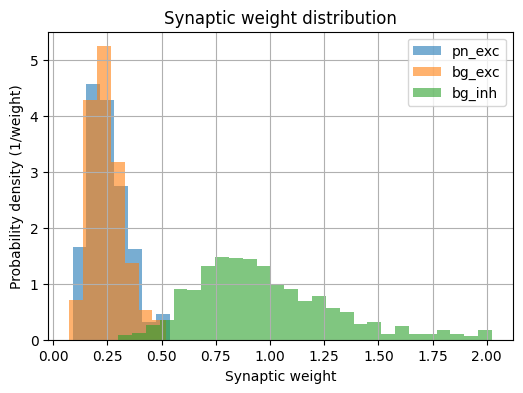

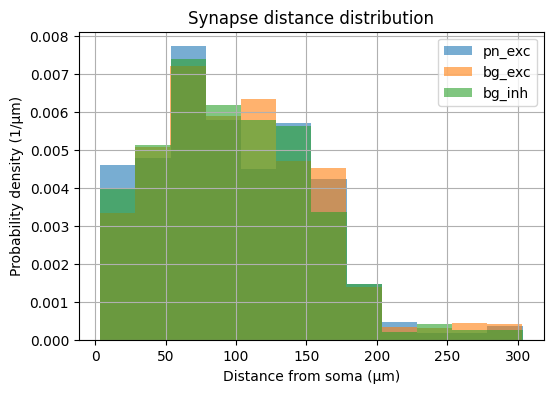

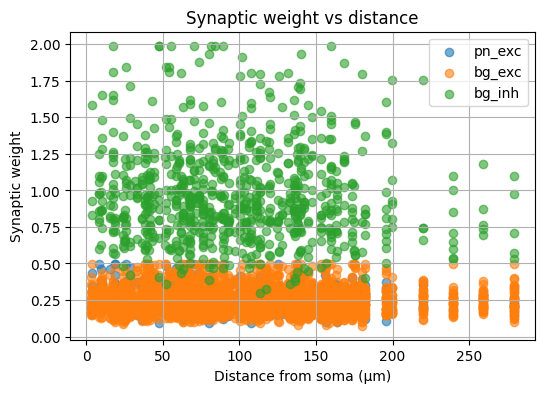

In [4]:
# Optional synapse-placement preview
preview_synapses = True     # True for a safe synapse-placement preview
preview_synapse_groups = None # None = each active group; "all" = aggregate groups
preview_synapse_plots = True  # Show summary table plus weight/distance plots

syn_state = None
if preview_synapses:
    syn_state = show_synapse_preview(
        session,
        trial_idx=0,
        groups=preview_synapse_groups,
        show_plots=preview_synapse_plots,
    )
else:
    print("Synapse preview disabled.")


## 5.4 Run Simulation and Save

Run the prepared session. Saving is controlled by `sim_config.json` plus the optional overrides from **5.1**.

Quick guide:
- If `saved_path` is `None`, the run stayed in memory only.
- To force a saved output folder for a notebook test, set `force_save = True` in **5.1** before running.
- Saved runs are written under `cells/<CELL>/tunes/<TUNE>/output_data/<RUN>/` unless `output_dir` overrides the parent directory.



In [5]:
# Run simulation and save according to sim_config/options
results = session.run()
saved_path = session.save()

if saved_path is None:
    print("Results not saved. Enable saving in sim_config or set force_save=True.")
else:
    print("Results saved to:", saved_path)


save_plots single_plot warning: Top input panel: group list empty, auto-using all groups (3).
Results saved to: /home/hrbncv/SCP/cells/SST/tunes/tuned/output_data/notebook_single_trial/run_manifest.json


## 5.5 Quick Diagnostics

Display lightweight diagnostics for the just-finished run. This is intentionally separate from the full Step 6 analysis workflow.

Quick guide:
- `diagnostic_plot = "summary"`: compact voltage summary.
- `diagnostic_plot = "standard"`: default notebook trace plot.
- `diagnostic_plot = "single_plot"`: more polished plotting preset when available.
- `diagnostic_plot = None`: skip inline plotting and print summaries only.
- `diagnostic_include_inputs`: include input summaries/plots when available.



Mode: single
Spike counts: [3]
Mean spikes/trial: 3.0
Detected 3 spikes (total avg: 3.0) at times (ms): [445.875 542.675 752.05 ]


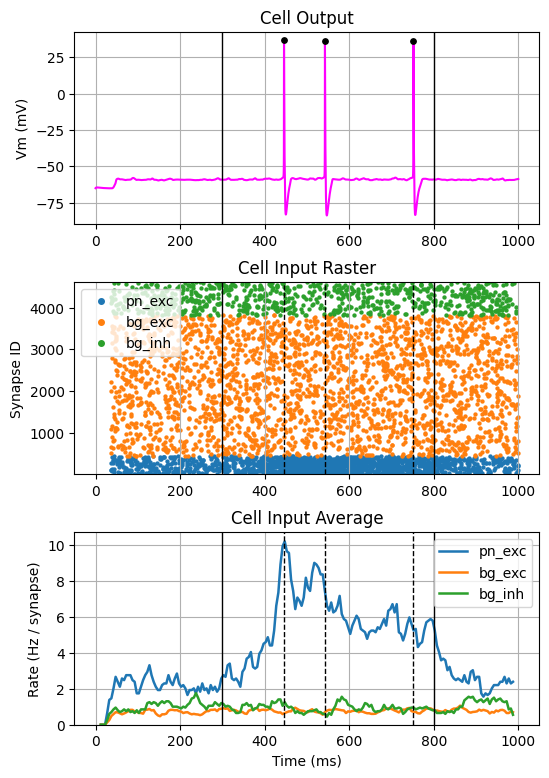

In [6]:
# Quick diagnostics: spike counts plus optional result plot
diagnostic_plot = "standard"  # "summary", "standard", "single_plot", or None
diagnostic_include_inputs = True

diagnostics = show_run_diagnostics(
    results,
    diagnostic_plot=diagnostic_plot,
    include_inputs=diagnostic_include_inputs,
    cell_name=cell_name,
    tune_name=tune_name,
    repo_root=repo_root,
)


## 5.6 Optional Manual Save

Use this only when you ran without saving, reviewed diagnostics, and then decided the run is worth keeping.

Quick guide:
- `manual_save`: set `True` after a run exists in memory.
- `manual_output_stem`: folder/run stem for the saved copy.
- `manual_note`: optional note stored in run metadata.
- `manual_color`: optional plot color override stored in config metadata.



In [7]:
# Optional: save this run after reviewing diagnostics
manual_save = False
manual_output_stem = "notebook_keep"  # change this before setting manual_save=True
manual_note = ""                     # optional note stored in meta
manual_color = None                   # optional plot color override, e.g. "m"

if manual_save:
    if "results" not in globals():
        raise RuntimeError("No results found. Run the simulation cell first.")

    results.setdefault("sim_cfg", {})["save_output"] = True
    results["sim_cfg"]["output"] = manual_output_stem
    if manual_color is not None:
        results["sim_cfg"]["color"] = manual_color
    if manual_note:
        results.setdefault("meta", {})["note"] = manual_note

    saved_path = run_sim.save_results(results, base_dir=tune_dir / "output_data")
    print("Manual save path:", saved_path)
else:
    print("Manual save disabled.")


Manual save disabled.


## 5.7 Optional Utilities

These cells are optional conveniences after a run has completed.

Quick guide:
- Use the load cell when you want to inspect a previously saved run without rerunning the simulation.
- `load_previous`: set `True` to load `previous_run`.
- `previous_run`: path to an `output_data/<run_name>` folder or a `run_manifest.json` file.

In [8]:
# Optional: load a previous saved run
load_previous = False
previous_run = tune_dir / "output_data" / "<run_name>"  # folder or run_manifest.json

if load_previous:
    results = run_sim.load_results(previous_run)
    print("Loaded:", previous_run)
    print("Mode:", results.get("mode"))
